# CO₂ Injection Rate Analysis — China Sedimentary Basins

**Part 1** — Basin centroid computation from the USGS sedimentary basin shapefile and literature sources.  
**Part 2** — Injection rate plots (bar chart + circle map) from Wu et al. (2023), *Scientific Data*.

| Source | Basins |
|---|---|
| USGS sed_basins shapefile | 20 |
| Published literature | 4 (Sanjiang, Yingen-Ejina, Hehuai, Qiongdongnan) |

Province boundaries: GADM 3.6, China level-1.

In [53]:
import shapefile
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape
from shapely.ops import unary_union
import cartopy.io.shapereader as shpreader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

## Part 1 — Basin Centroids

In [54]:
# Province boundaries (used as map background throughout)
GEOJSON = '/Users/al3792/Documents_Local/MacroEnergy.jl/ExampleSystems/gadm36_CHN_1.json'
gdf = gpd.read_file(GEOJSON)
gdf["NAME_1"] = gdf["NAME_1"].replace({
    "Nei Mongol":     "Innermongolia",
    "Ningxia Hui":    "Ningxia",
    "Xinjiang Uygur": "Xinjiang",
    "Xizang":         "Tibet",
})
gdf_proj = gdf.to_crs(epsg=3857)

In [55]:
# Load USGS sedimentary basin shapefile and preview records
SHP_PATH = "usgs_source/sed_basins/sed_basins.shp"
sf = shapefile.Reader(SHP_PATH)
print("Fields:", [f[0] for f in sf.fields[1:]])
print(f"Total records: {len(sf.records())}\n")
for i, r in enumerate(sf.records()):
    print(f"{i:>2}: {r[4]}")

Fields: ['AREA', 'PERIMETER', 'AGE_BASIN_', 'AGE_BASIN_', 'NAME', 'ERA']
Total records: 43

 0: Hailar Basin
 1: Songliao Basin
 2: Bayanhuxu-Eren Basin
 3: Junggar Basin
 4: Turpan-Hami Basin
 5: Tarim Basin
 6: Bohai Bay Basin
 7: Jiuquan-Minle Basin
 8: Ordos Basin
 9: Qaidam Basin
10: North Yellow Sea Basin
11: Quinshi-Linfen Basin
12: Northern South Yellow Sea Basin
13: Tsushima Basin
14: Northern Jiangsu-Southern South Yellow Sea Basin
15: East China Sea Shelf Basin
16: Tosa Bay Basin
17: Nanyang-Xiangfang Basin
18: Sichuan Basin
19: Miyazaki Basin
20: Okinawa Trough Basin
21: Lunpola-Baingoin Basin
22: Jianghan Basin
23: Dongting Basin
24: Amami Basin
25: Ryukyu Island Shimajiri Basin
26: Northwestern Taiwan Basin
27: Erhai Basin
28: Jinggu Basin
29: Bose Basin
30: Southwestern Taiwan Basin
31: Sanshui Basin
32: Zhujiangkou (Pearle R. Mouth) Basin
33: Beibu Gulf Basin
34: 
35: 
36: South Bijia Basin
37: North Shuangfeng Basin
38: North Shuangfeng Basin
39: North Shuangfeng Basin

In [56]:
# Split Bohai Bay Basin (record 6) into onshore and offshore parts
# using Natural Earth 10m land polygons as the land/ocean mask.
_land_shp  = shpreader.natural_earth(resolution="10m", category="physical", name="land")
_land_geom = unary_union([g for g in shpreader.Reader(_land_shp).geometries()])

_bohai_full = shape(sf.shape(6).__geo_interface__)
_bohai_on   = _bohai_full.intersection(_land_geom)
_bohai_off  = _bohai_full.difference(_land_geom)

print(f"Bohai Bay onshore  centroid: ({_bohai_on.centroid.y:.4f} N, {_bohai_on.centroid.x:.4f} E)")
print(f"Bohai Bay offshore centroid: ({_bohai_off.centroid.y:.4f} N, {_bohai_off.centroid.x:.4f} E)")

GEOM_OVERRIDES = {
    "Bohai Bay Basin (onshore)":  _bohai_on,
    "Bohai Bay Basin (offshore)": _bohai_off,
}

Bohai Bay onshore  centroid: (38.1531 N, 117.0270 E)
Bohai Bay offshore centroid: (39.0081 N, 119.7405 E)


In [57]:
# Map each of the 24 target basins to a shapefile record index.
# None = absent from shapefile; centroid comes from literature (next cell).
BASIN_MAP = [
    # (basin name,                       shapefile index,  type)
    # --- Onshore ---
    ("Songliao Basin",                   1,        "onshore"),
    ("Turpan-Hami Basin",                4,        "onshore"),
    ("Subei Basin",                      14,       "onshore"),
    ("Bohai Bay Basin (onshore)",        6,        "onshore"),   # centroid from GEOM_OVERRIDES
    ("Qaidam Basin",                     9,        "onshore"),
    ("Nanxiang Basin",                   17,       "onshore"),
    ("Sanjiang Basin",                   None,     "onshore"),
    ("Hailar Basin",                     0,        "onshore"),
    ("Jianghan Basin",                   22,       "onshore"),
    ("Tarim Basin",                      5,        "onshore"),
    ("Ordos Basin",                      8,        "onshore"),
    ("Yingen-Ejina Basin",               None,     "onshore"),
    ("Hehuai Basin",                     None,     "onshore"),
    ("Qinshui Basin",                    11,       "onshore"),
    ("Erlian Basin",                     2,        "onshore"),
    ("Junggar Basin",                    3,        "onshore"),
    ("Sichuan Basin",                    18,       "onshore"),
    # --- Offshore ---
    ("Bohai Bay Basin (offshore)",       6,        "offshore"),  # centroid from GEOM_OVERRIDES
    ("North Yellow Sea Basin",           10,       "offshore"),
    ("South Yellow Sea Basin",           12,       "offshore"),
    ("East China Sea Basin",             15,       "offshore"),
    ("Pearl River Mouth Basin",          32,       "offshore"),
    ("Beibu Gulf Basin",                 33,       "offshore"),
    ("Qiongdongnan Basin",              None,      "offshore"),
]

print(f"Total target basins : {len(BASIN_MAP)}")
print(f"From shapefile      : {sum(1 for _, idx, _ in BASIN_MAP if idx is not None)}")
print(f"From literature     : {sum(1 for _, idx, _ in BASIN_MAP if idx is None)}")

Total target basins : 24
From shapefile      : 20
From literature     : 4


In [58]:
# Manually-researched centroids for basins absent from the USGS shapefile.
#
# Sanjiang Basin — He et al. (2012), J. Geophys. Eng. 9(2):147
#   Basin extent ~46–48 N, 130–134 E.
#
# Yingen-Ejina Basin — Wang et al. (2024), J. Geophys. Eng. 21(1):304
#   600 km EW intracratonic basin, western Inner Mongolia.
#
# Hehuai Basin — APEC (2005) CO2 Storage Prospectivity
#   Southern part of the North China Basin, ~32–36 N, 112–118 E.
#
# Qiongdongnan Basin — Zhao et al. (2022), Sci. China Earth Sci.
#   Extent 108°40'–112°35' E, 16°50'–19°00' N.

LITERATURE_CENTROIDS = {
    "Sanjiang Basin":     {"lon": 132.0, "lat": 47.0},
    "Yingen-Ejina Basin": {"lon": 101.5, "lat": 41.5},
    "Hehuai Basin":       {"lon": 115.0, "lat": 34.0},
    "Qiongdongnan Basin": {"lon": 110.6, "lat": 17.9},
}

for name, info in LITERATURE_CENTROIDS.items():
    print(f"{name}: ({info['lat']:.2f} N, {info['lon']:.2f} E)")

Sanjiang Basin: (47.00 N, 132.00 E)
Yingen-Ejina Basin: (41.50 N, 101.50 E)
Hehuai Basin: (34.00 N, 115.00 E)
Qiongdongnan Basin: (17.90 N, 110.60 E)


In [59]:
# Build centroid DataFrame for all 24 basins.
# Priority: GEOM_OVERRIDES > shapefile polygon > literature coordinates.
shapes_list = sf.shapes()
geoms = [shape(s.__geo_interface__) for s in shapes_list]

records = []
for basin_name, idx, basin_type in BASIN_MAP:
    if basin_name in GEOM_OVERRIDES:
        geom = GEOM_OVERRIDES[basin_name]
        c = geom.centroid
        records.append({
            "basin": basin_name, "type": basin_type,
            "lon": round(c.x, 4), "lat": round(c.y, 4),
            "source": "shapefile+split",
            "shapefile_name": sf.record(6)[4] + " (split by Natural Earth land mask)",
            "notes": "Bohai Bay polygon intersected with Natural Earth 10m land mask",
        })
    elif idx is None:
        lit = LITERATURE_CENTROIDS[basin_name]
        records.append({
            "basin": basin_name, "type": basin_type,
            "lon": lit["lon"], "lat": lit["lat"],
            "source": "literature", "shapefile_name": "—", "notes": "",
        })
    else:
        indices = [idx] if isinstance(idx, int) else idx
        geom = geoms[indices[0]] if len(indices) == 1 else unary_union([geoms[i] for i in indices])
        c = geom.centroid
        records.append({
            "basin": basin_name, "type": basin_type,
            "lon": round(c.x, 4), "lat": round(c.y, 4),
            "source": "shapefile",
            "shapefile_name": ", ".join(sf.record(i)[4] for i in indices),
            "notes": "",
        })

df = pd.DataFrame(records)
df.index = range(1, len(df) + 1)
df.index.name = "#"
df

,basin,type,lon,lat,source,shapefile_name,notes
#,,,,,,,
1,Songliao Basin,onshore,124.2489,45.5424,shapefile,Songliao Basin,
2,Turpan-Hami Basin,onshore,91.8474,42.7741,shapefile,Turpan-Hami Basin,
3,Subei Basin,onshore,120.2968,33.2802,shapefile,Northern Jiangsu-Southern South Yellow Sea Basin,
4,Bohai Bay Basin (onshore),onshore,117.0270,38.1531,shapefile+split,Bohai Bay Basin (split by Natural Earth land m...,Bohai Bay polygon intersected with Natural Ear...
5,Qaidam Basin,onshore,94.0675,37.4565,shapefile,Qaidam Basin,
6,Nanxiang Basin,onshore,112.3891,32.6284,shapefile,Nanyang-Xiangfang Basin,
7,Sanjiang Basin,onshore,132.0000,47.0000,literature,—,
8,Hailar Basin,onshore,118.5403,48.9011,shapefile,Hailar Basin,
9,Jianghan Basin,onshore,112.9206,30.4742,shapefile,Jianghan Basin,


In [60]:
# Export centroids to CSV
out = df[["basin", "type", "lon", "lat", "source", "shapefile_name", "notes"]].copy()
out.to_csv("usgs_source/basin_centroids_shapefile.csv", index_label="#")
print("Saved usgs_source/basin_centroids_shapefile.csv")

Saved usgs_source/basin_centroids_shapefile.csv


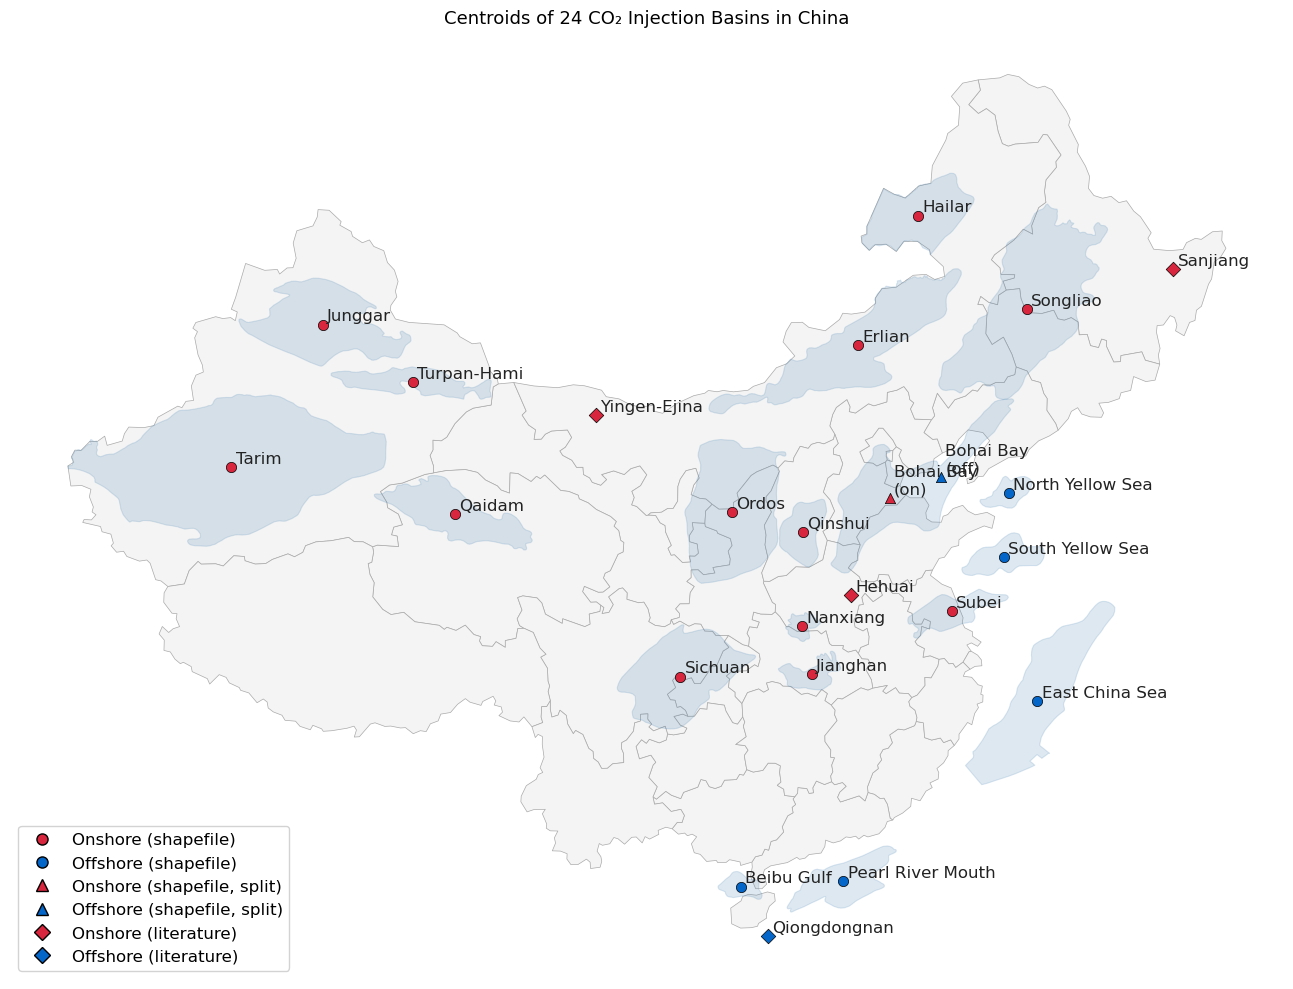

In [61]:
# Map: province background (GADM GeoJSON) + basin polygon outlines + centroids

# Build a GeoDataFrame of basin polygons from the shapefile for the matched basins
drawn_idx = set()
basin_poly_rows = []
for _, idx, _ in BASIN_MAP:
    if idx is None:
        continue
    for i in ([idx] if isinstance(idx, int) else idx):
        if i not in drawn_idx:
            drawn_idx.add(i)
            basin_poly_rows.append({"geometry": geoms[i], "name": sf.record(i)[4]})

basin_shp_gdf = gpd.GeoDataFrame(basin_poly_rows, crs="EPSG:4326").to_crs(epsg=3857)

# Project centroids to Web Mercator for consistent coordinates
centroid_gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs="EPSG:4326"
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_axis_off()

gdf_proj.plot(ax=ax, color="#F4F4F4", edgecolor="#AAAAAA", linewidth=0.5, zorder=0)
basin_shp_gdf.plot(ax=ax, color="steelblue", alpha=0.18, edgecolor="steelblue",
                   linewidth=0.8, zorder=1)

marker_map = {"shapefile": "o", "shapefile+split": "^", "literature": "D"}
color_map  = {"onshore": "#d7263d", "offshore": "#0466c8"}

for _, row in centroid_gdf.iterrows():
    ax.scatter(
        row.geometry.x, row.geometry.y,
        s=55, marker=marker_map[row["source"]],
        c=color_map[row["type"]], edgecolors="k", linewidths=0.5, zorder=4,
    )
    label = (row["basin"]
             .replace(" Basin", "")
             .replace(" (onshore)", "\n(on)")
             .replace(" (offshore)", "\n(off)"))
    ax.text(row.geometry.x + 25_000, row.geometry.y + 25_000, label,
            fontsize=12, zorder=5, color="#222222")

legend_elements = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#d7263d", markeredgecolor="k", markersize=8, label="Onshore (shapefile)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#0466c8", markeredgecolor="k", markersize=8, label="Offshore (shapefile)"),
    Line2D([0],[0], marker="^", color="w", markerfacecolor="#d7263d", markeredgecolor="k", markersize=8, label="Onshore (shapefile, split)"),
    Line2D([0],[0], marker="^", color="w", markerfacecolor="#0466c8", markeredgecolor="k", markersize=8, label="Offshore (shapefile, split)"),
    Line2D([0],[0], marker="D", color="w", markerfacecolor="#d7263d", markeredgecolor="k", markersize=8, label="Onshore (literature)"),
    Line2D([0],[0], marker="D", color="w", markerfacecolor="#0466c8", markeredgecolor="k", markersize=8, label="Offshore (literature)"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=12, framealpha=0.85)
plt.title("Centroids of 24 CO₂ Injection Basins in China", fontsize=13)
plt.tight_layout()
plt.savefig("usgs_source/basin_centroids_map.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 2 — Injection Rates (Deep Saline Aquifers)

Data: Wu et al. (2023), *Scientific Data* — `nature_scientific_data_source/injection_rates.csv`

In [62]:
# Load injection rates and harmonise basin names to match the centroid DataFrame
rates = pd.read_csv("nature_scientific_data_source/injection_rates.csv")
rates["Basin"] = rates["Basin"].replace({
    "Tuepan-Hami Basin": "Turpan-Hami Basin",
    "Ejinjina Basin":    "Yingen-Ejina Basin",
})
rates.head()

,Typology,Basin,Saline Aquifer Max (Mt/a),Saline Aquifer Min (Mt/a),Saline Aquifer Mean (Mt/a),Saline Aquifer SD (Mt/a),Oilfield Max (Mt/a),Oilfield Min (Mt/a),Oilfield Mean (Mt/a),Oilfield SD (Mt/a)
0,Onshore,Songliao Basin,1.64,0.02,0.42,0.30,55.77,0.00,7.05,13.62
1,Onshore,Turpan-Hami Basin,28.63,1.33,10.26,7.07,27.58,6.74,17.37,9.63
2,Onshore,Subei Basin,34.07,1.78,13.58,7.58,134.77,0.00,53.30,52.14
3,Onshore,Bohai Bay Basin (onshore),122.77,4.09,23.82,28.97,152.46,0.00,35.61,29.38
4,Onshore,Qaidam Basin,17.56,5.85,9.43,3.02,20.62,4.40,19.85,3.54


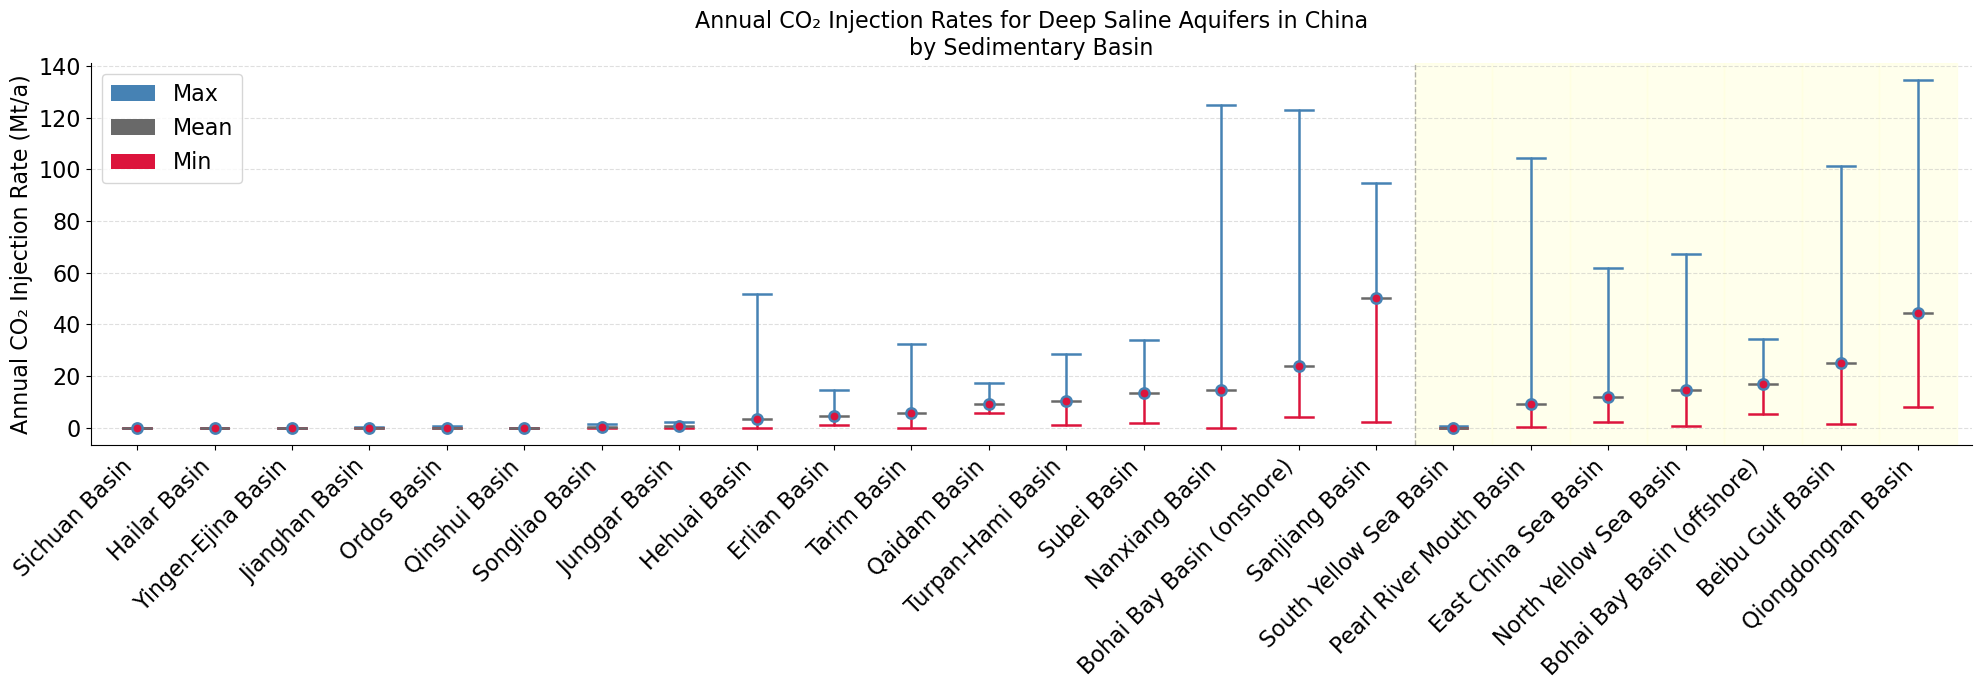

In [63]:
# Bar chart: min / mean / max saline aquifer injection rate per basin
# Onshore basins first, offshore second; sorted by mean within each group
rates_plot = rates.copy()
rates_plot["_order"] = rates_plot["Typology"].map({"Onshore": 0, "Offshore": 1})
rates_plot = rates_plot.sort_values(["_order", "Saline Aquifer Mean (Mt/a)"]).reset_index(drop=True)

basins   = rates_plot["Basin"].tolist()
means    = rates_plot["Saline Aquifer Mean (Mt/a)"].tolist()
mins     = rates_plot["Saline Aquifer Min (Mt/a)"].tolist()
maxs     = rates_plot["Saline Aquifer Max (Mt/a)"].tolist()
typology = rates_plot["Typology"].tolist()

n = len(basins)
tick_hw = 0.18

fig, ax = plt.subplots(figsize=(20, 7))

for i in range(n):
    mn, me, mx = mins[i], means[i], maxs[i]
    ax.plot([i, i], [me, mx], color="steelblue", linewidth=1.8, solid_capstyle="round")
    ax.plot([i, i], [mn, me], color="crimson",   linewidth=1.8, solid_capstyle="round")
    for y_val, color in [(mx, "steelblue"), (mn, "crimson"), (me, "dimgray")]:
        ax.plot([i - tick_hw, i + tick_hw], [y_val, y_val], color=color, linewidth=1.8)
    ax.scatter(i, me, color="crimson", edgecolors="steelblue", s=55, zorder=5, linewidths=1.8)

for i, typ in enumerate(typology):
    if typ == "Offshore":
        ax.axvspan(i - 0.5, i + 0.5, color="lightyellow", alpha=0.6, zorder=0)

n_onshore = typology.index("Offshore")
ax.axvline(n_onshore - 0.5, color="gray", linewidth=1, linestyle="--", alpha=0.6)

ax.set_xticks(range(n))
ax.set_xticklabels(basins, rotation=45, ha="right", fontsize=16)
ax.tick_params(axis="y", labelsize=16)
ax.set_xlim(-0.6, n - 0.3)
ax.set_ylabel("Annual CO₂ Injection Rate (Mt/a)", fontsize=16)
ax.set_title("Annual CO₂ Injection Rates for Deep Saline Aquifers in China\nby Sedimentary Basin", fontsize=16)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

ax.legend(
    handles=[
        mpatches.Patch(facecolor="steelblue",   label="Max"),
        mpatches.Patch(facecolor="dimgray",     label="Mean"),
        mpatches.Patch(facecolor="crimson",     label="Min"),
        #mpatches.Patch(facecolor="lightyellow", edgecolor="gray", alpha=0.8, label="Offshore"),
    ],
    loc="upper left", fontsize=16, framealpha=0.8
)

plt.tight_layout()
plt.savefig("nature_scientific_data_source/injection_rates_saline_aquifers.png", dpi=150, bbox_inches="tight")
plt.show()

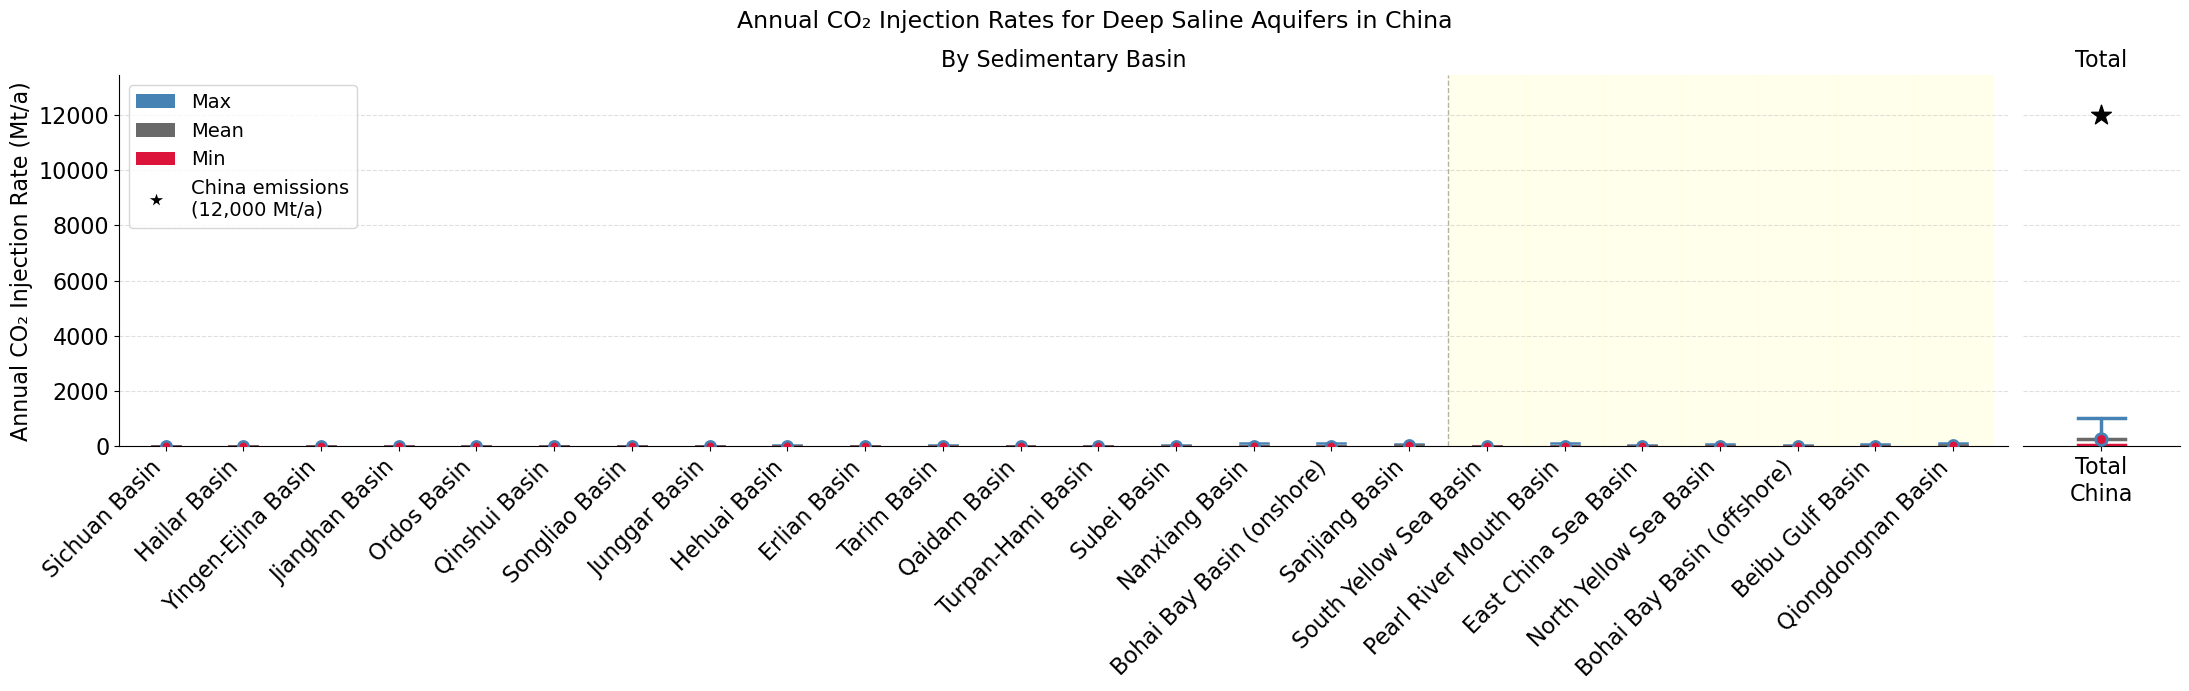

Total injection capacity — min: 35  mean: 260  max: 1031 Mt/a
China annual emissions: 12,000 Mt/a


In [64]:
# Bar chart v2: per-basin (left) + total China (right), shared y-scale
# China total annual CO₂ emissions ~12,000 Mt/a (Global Carbon Project, 2023)

CHINA_EMISSIONS_MTA = 12_000

total_min  = rates["Saline Aquifer Min (Mt/a)"].sum()
total_mean = rates["Saline Aquifer Mean (Mt/a)"].sum()
total_max  = rates["Saline Aquifer Max (Mt/a)"].sum()

y_max = CHINA_EMISSIONS_MTA * 1.12   # headroom above the emissions marker

fig, (ax_l, ax_r) = plt.subplots(
    1, 2, figsize=(22, 7),
    gridspec_kw={"width_ratios": [24, 2]},
    sharey=True
)

# ── LEFT: per-basin ────────────────────────────────────────────────────────────
for i in range(n):
    mn, me, mx = mins[i], means[i], maxs[i]
    ax_l.plot([i, i], [me, mx], color="steelblue", linewidth=1.8, solid_capstyle="round")
    ax_l.plot([i, i], [mn, me], color="crimson",   linewidth=1.8, solid_capstyle="round")
    for y_val, color in [(mx, "steelblue"), (mn, "crimson"), (me, "dimgray")]:
        ax_l.plot([i - tick_hw, i + tick_hw], [y_val, y_val], color=color, linewidth=1.8)
    ax_l.scatter(i, me, color="crimson", edgecolors="steelblue", s=55, zorder=5, linewidths=1.8)

for i, typ in enumerate(typology):
    if typ == "Offshore":
        ax_l.axvspan(i - 0.5, i + 0.5, color="lightyellow", alpha=0.6, zorder=0)

ax_l.axvline(n_onshore - 0.5, color="gray", linewidth=1, linestyle="--", alpha=0.6)
ax_l.set_xticks(range(n))
ax_l.set_xticklabels(basins, rotation=45, ha="right", fontsize=16)
ax_l.tick_params(axis="y", labelsize=16)
ax_l.set_xlim(-0.6, n - 0.3)
ax_l.set_ylabel("Annual CO₂ Injection Rate (Mt/a)", fontsize=16)
ax_l.set_title("By Sedimentary Basin", fontsize=16)
ax_l.grid(axis="y", linestyle="--", alpha=0.4)
ax_l.spines[["top", "right"]].set_visible(False)

ax_l.legend(
    handles=[
        mpatches.Patch(facecolor="steelblue", label="Max"),
        mpatches.Patch(facecolor="dimgray",   label="Mean"),
        mpatches.Patch(facecolor="crimson",   label="Min"),
        Line2D([0],[0], marker="*", color="w", markerfacecolor="black",
               markersize=13, label=f"China emissions\n({CHINA_EMISSIONS_MTA:,} Mt/a)"),
    ],
    loc="upper left", fontsize=14, framealpha=0.8
)

# ── RIGHT: total China ────────────────────────────────────────────────────────
ax_r.plot([0, 0], [total_mean, total_max], color="steelblue", linewidth=2.5, solid_capstyle="round")
ax_r.plot([0, 0], [total_min, total_mean], color="crimson",   linewidth=2.5, solid_capstyle="round")
for y_val, color in [(total_max, "steelblue"), (total_min, "crimson"), (total_mean, "dimgray")]:
    ax_r.plot([-tick_hw, tick_hw], [y_val, y_val], color=color, linewidth=2.5)
ax_r.scatter(0, total_mean, color="crimson", edgecolors="steelblue", s=70, zorder=5, linewidths=2)

# China total emissions reference point
ax_r.scatter(0, CHINA_EMISSIONS_MTA, color="black", marker="*", s=220, zorder=6)

ax_r.set_xticks([0])
ax_r.set_xticklabels(["Total\nChina"], fontsize=16)
ax_r.set_xlim(-0.6, 0.6)
ax_r.set_title("Total", fontsize=16)
ax_r.grid(axis="y", linestyle="--", alpha=0.4)
ax_r.spines[["top", "right", "left"]].set_visible(False)
ax_r.tick_params(axis="y", left=False)

# Shared y-limits (set on one axis; sharey propagates to the other)
ax_l.set_ylim(0, y_max)

fig.suptitle("Annual CO₂ Injection Rates for Deep Saline Aquifers in China", fontsize=17)
plt.tight_layout()
plt.savefig("nature_scientific_data_source/injection_rates_saline_aquifers_with_total.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Total injection capacity — min: {total_min:.0f}  mean: {total_mean:.0f}  max: {total_max:.0f} Mt/a")
print(f"China annual emissions: {CHINA_EMISSIONS_MTA:,} Mt/a")

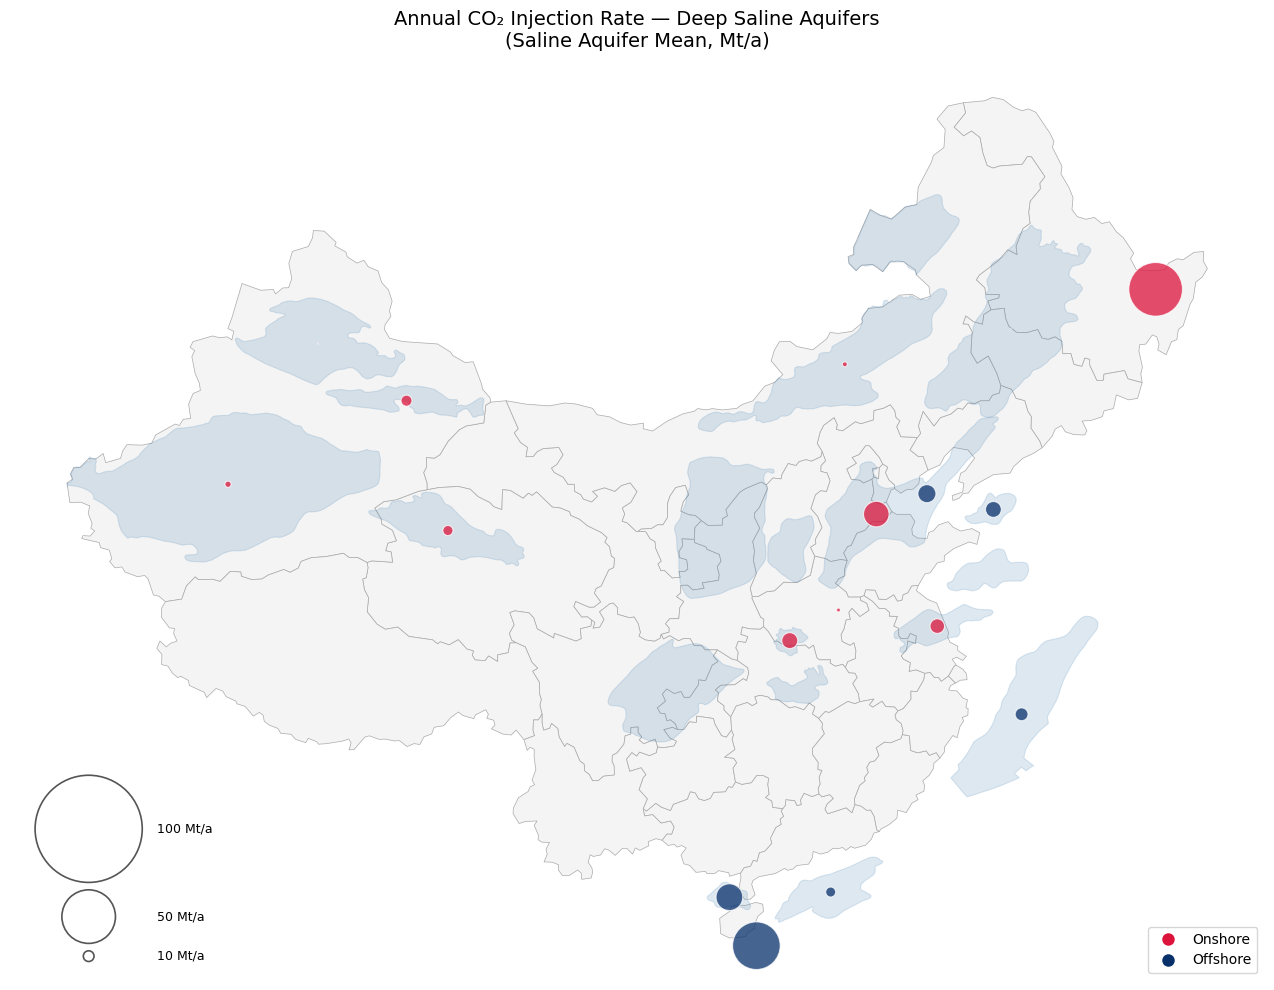

In [65]:
# Circle map v2 — built on top of the centroid map's projection pipeline
# Uses centroid_gdf (already in EPSG:3857) merged with injection rates.
# No text labels.

# ── CONFIG ────────────────────────────────────────────────────────────────────
VALUE_COL    = "Saline Aquifer Mean (Mt/a)"  # swap in Min / Max / SD as needed
PIE_SCALE    = 2.0
LEGEND_SIZES = [10, 50, 100]                 # Mt/a reference circles

# ── MERGE injection rates into centroid_gdf (already EPSG:3857) ───────────────
circ_gdf = centroid_gdf.merge(rates[["Basin", VALUE_COL]], left_on="basin", right_on="Basin", how="left")
circ_gdf["cx"] = circ_gdf.geometry.x
circ_gdf["cy"] = circ_gdf.geometry.y

max_val = circ_gdf[VALUE_COL].max()
circ_gdf["radius"] = (circ_gdf[VALUE_COL] / max_val) * PIE_SCALE * 80_000

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_axis_off()

gdf_proj.plot(ax=ax, color="#F4F4F4", edgecolor="#AAAAAA", linewidth=0.5, zorder=0)
basin_shp_gdf.plot(ax=ax, color="steelblue", alpha=0.18, edgecolor="steelblue",
                   linewidth=0.8, zorder=1)

onshore_color  = "crimson"
offshore_color = "#08306b"

for _, row in circ_gdf.iterrows():
    val = row[VALUE_COL]
    if pd.isna(val) or val == 0:
        continue
    color = onshore_color if row["type"] == "onshore" else offshore_color
    ax.add_patch(Circle(
        (row["cx"], row["cy"]), row["radius"],
        facecolor=color, edgecolor="white", linewidth=0.8, alpha=0.75, zorder=10
    ))

# ── SIZE LEGEND ───────────────────────────────────────────────────────────────
xlim, ylim   = ax.get_xlim(), ax.get_ylim()
plot_w, plot_h = xlim[1] - xlim[0], ylim[1] - ylim[0]
pad_x, pad_y = plot_w * 0.02, plot_h * 0.02
legend_radii = [(s / max_val) * PIE_SCALE * 80_000 for s in LEGEND_SIZES]
max_r        = max(legend_radii)
legend_cx    = xlim[0] + pad_x + max_r

y = ylim[0] + pad_y
for size, radius in sorted(zip(LEGEND_SIZES, legend_radii)):
    cy_leg = y + radius
    ax.add_patch(Circle(
        (legend_cx, cy_leg), radius,
        facecolor="white", edgecolor="#555555", linewidth=1.2, zorder=20
    ))
    ax.text(legend_cx + max_r + pad_x * 0.6, cy_leg,
            f"{size} Mt/a", va="center", ha="left", fontsize=9, zorder=21)
    y += radius * 2 + pad_y * 0.4

# ── COLOUR LEGEND ─────────────────────────────────────────────────────────────
ax.legend(
    handles=[
        Line2D([0],[0], marker="o", color="w", markerfacecolor=onshore_color,
               markeredgecolor="white", markersize=10, label="Onshore"),
        Line2D([0],[0], marker="o", color="w", markerfacecolor=offshore_color,
               markeredgecolor="white", markersize=10, label="Offshore"),
    ],
    loc="lower right", fontsize=10, framealpha=0.8
)

col_label = VALUE_COL.replace(" (Mt/a)", "")
plt.title(f"Annual CO₂ Injection Rate — Deep Saline Aquifers\n({col_label}, Mt/a)", fontsize=14)
plt.tight_layout()
plt.savefig(
    f"nature_scientific_data_source/injection_rates_map_{col_label.lower().replace(' ', '_')}_v2.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

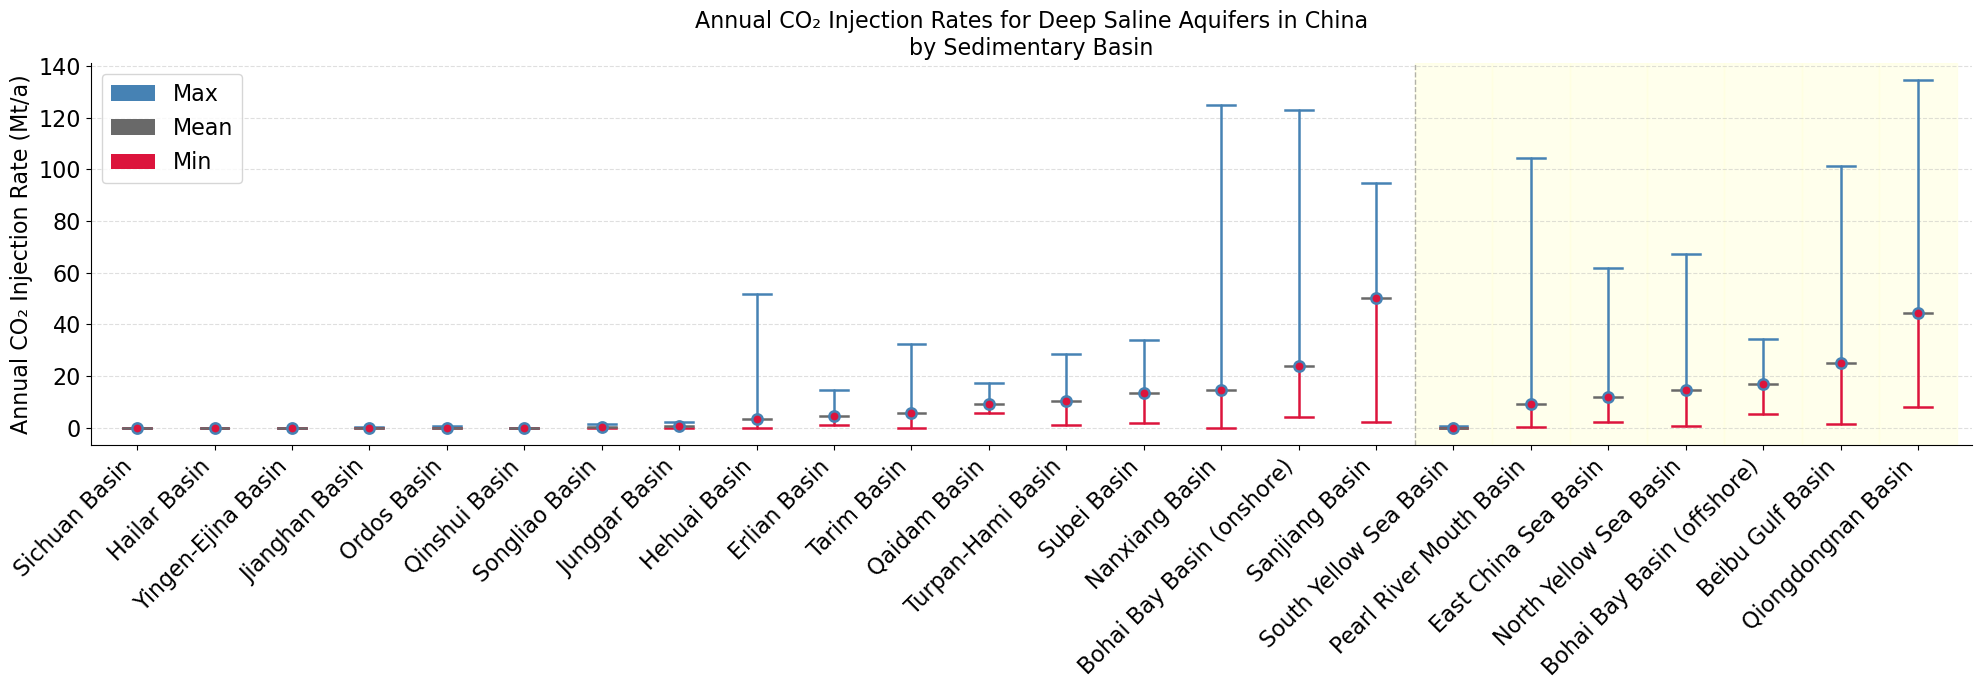

In [66]:
# Bar chart: min / mean / max saline aquifer injection rate per basin
# Onshore basins first, offshore second; sorted by mean within each group
rates_plot = rates.copy()
rates_plot["_order"] = rates_plot["Typology"].map({"Onshore": 0, "Offshore": 1})
rates_plot = rates_plot.sort_values(["_order", "Saline Aquifer Mean (Mt/a)"]).reset_index(drop=True)

basins   = rates_plot["Basin"].tolist()
means    = rates_plot["Saline Aquifer Mean (Mt/a)"].tolist()
mins     = rates_plot["Saline Aquifer Min (Mt/a)"].tolist()
maxs     = rates_plot["Saline Aquifer Max (Mt/a)"].tolist()
typology = rates_plot["Typology"].tolist()

n = len(basins)
tick_hw = 0.18

fig, ax = plt.subplots(figsize=(20, 7))

for i in range(n):
    mn, me, mx = mins[i], means[i], maxs[i]
    ax.plot([i, i], [me, mx], color="steelblue", linewidth=1.8, solid_capstyle="round")
    ax.plot([i, i], [mn, me], color="crimson",   linewidth=1.8, solid_capstyle="round")
    for y_val, color in [(mx, "steelblue"), (mn, "crimson"), (me, "dimgray")]:
        ax.plot([i - tick_hw, i + tick_hw], [y_val, y_val], color=color, linewidth=1.8)
    ax.scatter(i, me, color="crimson", edgecolors="steelblue", s=55, zorder=5, linewidths=1.8)

for i, typ in enumerate(typology):
    if typ == "Offshore":
        ax.axvspan(i - 0.5, i + 0.5, color="lightyellow", alpha=0.6, zorder=0)

n_onshore = typology.index("Offshore")
ax.axvline(n_onshore - 0.5, color="gray", linewidth=1, linestyle="--", alpha=0.6)

ax.set_xticks(range(n))
ax.set_xticklabels(basins, rotation=45, ha="right", fontsize=16)
ax.tick_params(axis="y", labelsize=16)
ax.set_xlim(-0.6, n - 0.3)
ax.set_ylabel("Annual CO₂ Injection Rate (Mt/a)", fontsize=16)
ax.set_title("Annual CO₂ Injection Rates for Deep Saline Aquifers in China\nby Sedimentary Basin", fontsize=16)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

ax.legend(
    handles=[
        mpatches.Patch(facecolor="steelblue",   label="Max"),
        mpatches.Patch(facecolor="dimgray",     label="Mean"),
        mpatches.Patch(facecolor="crimson",     label="Min"),
        #mpatches.Patch(facecolor="lightyellow", edgecolor="gray", alpha=0.8, label="Offshore"),
    ],
    loc="upper left", fontsize=16, framealpha=0.8
)

plt.tight_layout()
plt.savefig("nature_scientific_data_source/injection_rates_saline_aquifers.png", dpi=150, bbox_inches="tight")
plt.show()

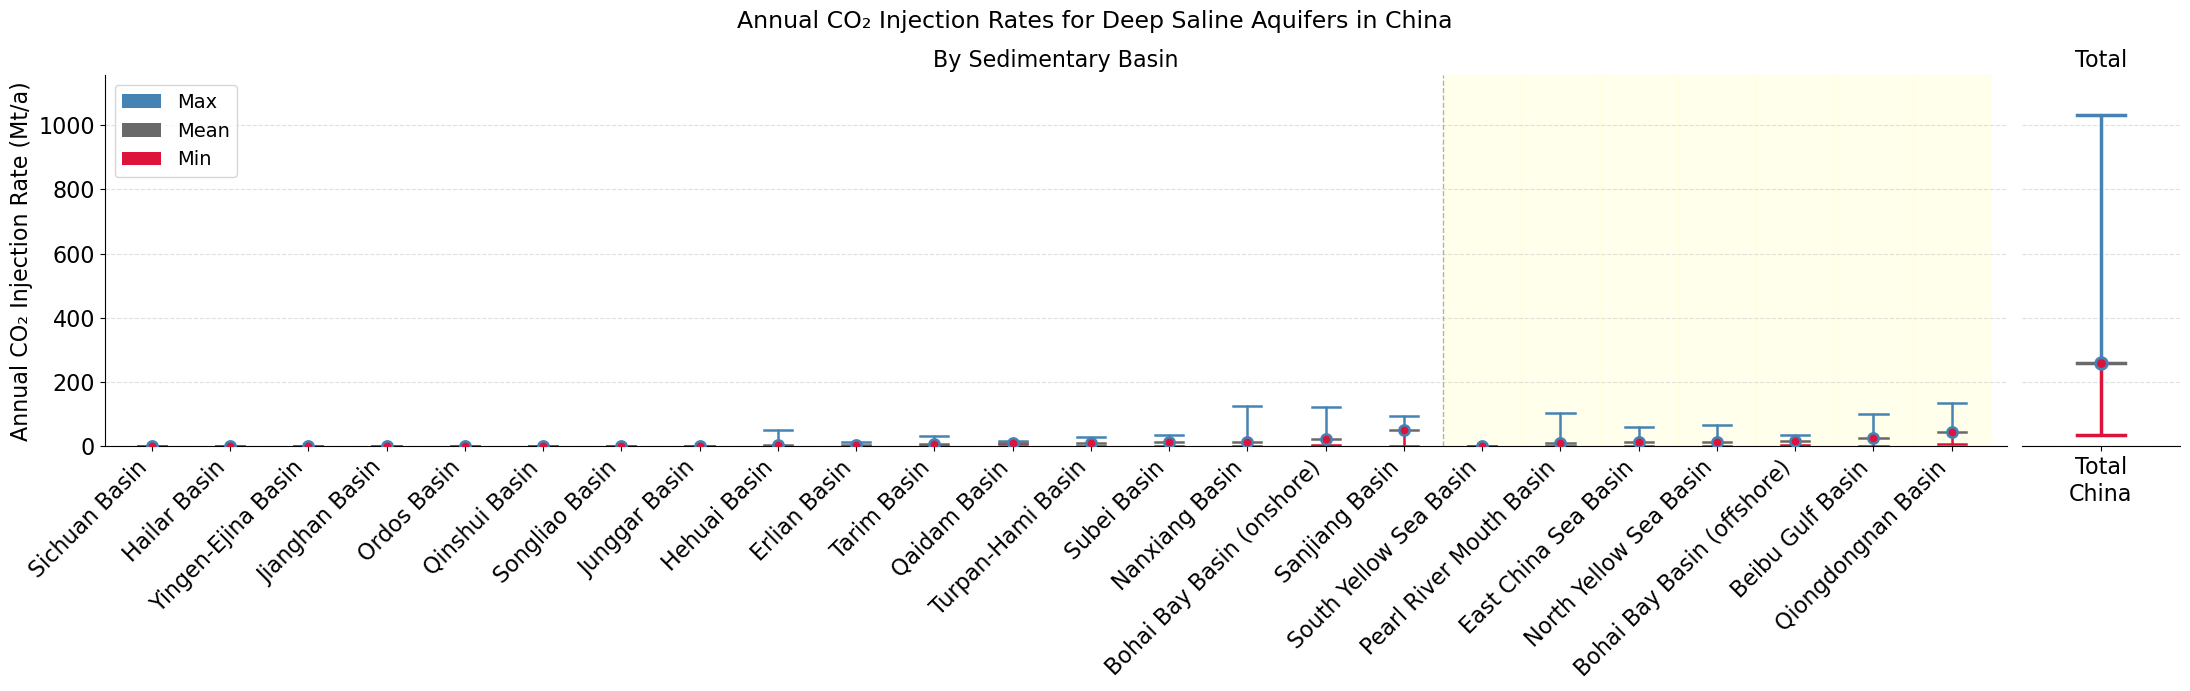

Total injection capacity — min: 35  mean: 260  max: 1031 Mt/a
China annual emissions: 12,000 Mt/a


In [73]:
# Bar chart v2: per-basin (left) + total China (right), shared y-scale
# China total annual CO₂ emissions ~12,000 Mt/a (Global Carbon Project, 2023)


total_min  = rates["Saline Aquifer Min (Mt/a)"].sum()
total_mean = rates["Saline Aquifer Mean (Mt/a)"].sum()
total_max  = rates["Saline Aquifer Max (Mt/a)"].sum()

y_max = total_max * 1.12   # headroom above the emissions marker

fig, (ax_l, ax_r) = plt.subplots(
    1, 2, figsize=(22, 7),
    gridspec_kw={"width_ratios": [24, 2]},
    sharey=True
)

# ── LEFT: per-basin ────────────────────────────────────────────────────────────
for i in range(n):
    mn, me, mx = mins[i], means[i], maxs[i]
    ax_l.plot([i, i], [me, mx], color="steelblue", linewidth=1.8, solid_capstyle="round")
    ax_l.plot([i, i], [mn, me], color="crimson",   linewidth=1.8, solid_capstyle="round")
    for y_val, color in [(mx, "steelblue"), (mn, "crimson"), (me, "dimgray")]:
        ax_l.plot([i - tick_hw, i + tick_hw], [y_val, y_val], color=color, linewidth=1.8)
    ax_l.scatter(i, me, color="crimson", edgecolors="steelblue", s=55, zorder=5, linewidths=1.8)

for i, typ in enumerate(typology):
    if typ == "Offshore":
        ax_l.axvspan(i - 0.5, i + 0.5, color="lightyellow", alpha=0.6, zorder=0)

ax_l.axvline(n_onshore - 0.5, color="gray", linewidth=1, linestyle="--", alpha=0.6)
ax_l.set_xticks(range(n))
ax_l.set_xticklabels(basins, rotation=45, ha="right", fontsize=16)
ax_l.tick_params(axis="y", labelsize=16)
ax_l.set_xlim(-0.6, n - 0.3)
ax_l.set_ylabel("Annual CO₂ Injection Rate (Mt/a)", fontsize=16)
ax_l.set_title("By Sedimentary Basin", fontsize=16)
ax_l.grid(axis="y", linestyle="--", alpha=0.4)
ax_l.spines[["top", "right"]].set_visible(False)

ax_l.legend(
    handles=[
        mpatches.Patch(facecolor="steelblue", label="Max"),
        mpatches.Patch(facecolor="dimgray",   label="Mean"),
        mpatches.Patch(facecolor="crimson",   label="Min")
    ],
    loc="upper left", fontsize=14, framealpha=0.8
)

# ── RIGHT: total China ────────────────────────────────────────────────────────
ax_r.plot([0, 0], [total_mean, total_max], color="steelblue", linewidth=2.5, solid_capstyle="round")
ax_r.plot([0, 0], [total_min, total_mean], color="crimson",   linewidth=2.5, solid_capstyle="round")
for y_val, color in [(total_max, "steelblue"), (total_min, "crimson"), (total_mean, "dimgray")]:
    ax_r.plot([-tick_hw, tick_hw], [y_val, y_val], color=color, linewidth=2.5)
ax_r.scatter(0, total_mean, color="crimson", edgecolors="steelblue", s=70, zorder=5, linewidths=2)


ax_r.set_xticks([0])
ax_r.set_xticklabels(["Total\nChina"], fontsize=16)
ax_r.set_xlim(-0.6, 0.6)
ax_r.set_title("Total", fontsize=16)
ax_r.grid(axis="y", linestyle="--", alpha=0.4)
ax_r.spines[["top", "right", "left"]].set_visible(False)
ax_r.tick_params(axis="y", left=False)

# Shared y-limits (set on one axis; sharey propagates to the other)
ax_l.set_ylim(0, y_max)

fig.suptitle("Annual CO₂ Injection Rates for Deep Saline Aquifers in China", fontsize=17)
plt.tight_layout()
plt.savefig("nature_scientific_data_source/injection_rates_saline_aquifers_with_total.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Total injection capacity — min: {total_min:.0f}  mean: {total_mean:.0f}  max: {total_max:.0f} Mt/a")
print(f"China annual emissions: {CHINA_EMISSIONS_MTA:,} Mt/a")

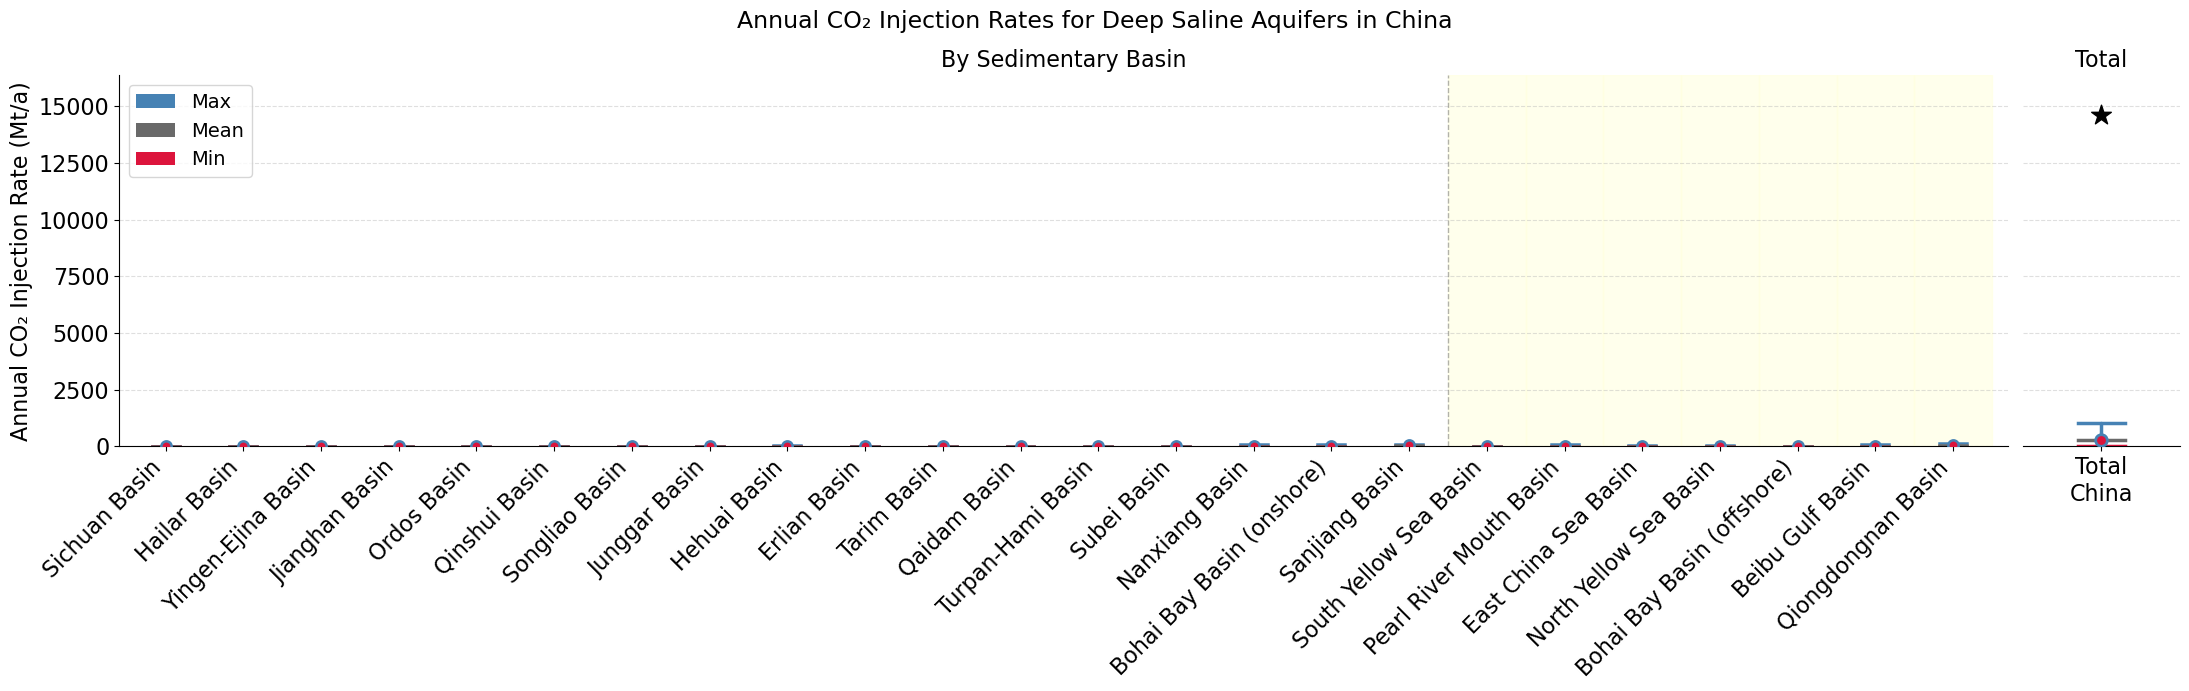

Total injection capacity — min: 35  mean: 260  max: 1031 Mt/a
China annual emissions: 14,612 Mt/a


In [74]:
# Bar chart v2: per-basin (left) + total China (right), shared y-scale
# China total annual CO₂ emissions ~12,000 Mt/a (Global Carbon Project, 2023)

CHINA_EMISSIONS_MTA = 14_612

total_min  = rates["Saline Aquifer Min (Mt/a)"].sum()
total_mean = rates["Saline Aquifer Mean (Mt/a)"].sum()
total_max  = rates["Saline Aquifer Max (Mt/a)"].sum()

y_max = CHINA_EMISSIONS_MTA * 1.12   # headroom above the emissions marker

fig, (ax_l, ax_r) = plt.subplots(
    1, 2, figsize=(22, 7),
    gridspec_kw={"width_ratios": [24, 2]},
    sharey=True
)

# ── LEFT: per-basin ────────────────────────────────────────────────────────────
for i in range(n):
    mn, me, mx = mins[i], means[i], maxs[i]
    ax_l.plot([i, i], [me, mx], color="steelblue", linewidth=1.8, solid_capstyle="round")
    ax_l.plot([i, i], [mn, me], color="crimson",   linewidth=1.8, solid_capstyle="round")
    for y_val, color in [(mx, "steelblue"), (mn, "crimson"), (me, "dimgray")]:
        ax_l.plot([i - tick_hw, i + tick_hw], [y_val, y_val], color=color, linewidth=1.8)
    ax_l.scatter(i, me, color="crimson", edgecolors="steelblue", s=55, zorder=5, linewidths=1.8)

for i, typ in enumerate(typology):
    if typ == "Offshore":
        ax_l.axvspan(i - 0.5, i + 0.5, color="lightyellow", alpha=0.6, zorder=0)

ax_l.axvline(n_onshore - 0.5, color="gray", linewidth=1, linestyle="--", alpha=0.6)
ax_l.set_xticks(range(n))
ax_l.set_xticklabels(basins, rotation=45, ha="right", fontsize=16)
ax_l.tick_params(axis="y", labelsize=16)
ax_l.set_xlim(-0.6, n - 0.3)
ax_l.set_ylabel("Annual CO₂ Injection Rate (Mt/a)", fontsize=16)
ax_l.set_title("By Sedimentary Basin", fontsize=16)
ax_l.grid(axis="y", linestyle="--", alpha=0.4)
ax_l.spines[["top", "right"]].set_visible(False)

ax_l.legend(
    handles=[
        mpatches.Patch(facecolor="steelblue", label="Max"),
        mpatches.Patch(facecolor="dimgray",   label="Mean"),
        mpatches.Patch(facecolor="crimson",   label="Min"),
    ],
    loc="upper left", fontsize=14, framealpha=0.8
)

# ── RIGHT: total China ────────────────────────────────────────────────────────
ax_r.plot([0, 0], [total_mean, total_max], color="steelblue", linewidth=2.5, solid_capstyle="round")
ax_r.plot([0, 0], [total_min, total_mean], color="crimson",   linewidth=2.5, solid_capstyle="round")
for y_val, color in [(total_max, "steelblue"), (total_min, "crimson"), (total_mean, "dimgray")]:
    ax_r.plot([-tick_hw, tick_hw], [y_val, y_val], color=color, linewidth=2.5)
ax_r.scatter(0, total_mean, color="crimson", edgecolors="steelblue", s=70, zorder=5, linewidths=2)

# China total emissions reference point
ax_r.scatter(0, CHINA_EMISSIONS_MTA, color="black", marker="*", s=220, zorder=6)

ax_r.set_xticks([0])
ax_r.set_xticklabels(["Total\nChina"], fontsize=16)
ax_r.set_xlim(-0.6, 0.6)
ax_r.set_title("Total", fontsize=16)
ax_r.grid(axis="y", linestyle="--", alpha=0.4)
ax_r.spines[["top", "right", "left"]].set_visible(False)
ax_r.tick_params(axis="y", left=False)

# Shared y-limits (set on one axis; sharey propagates to the other)
ax_l.set_ylim(0, y_max)

fig.suptitle("Annual CO₂ Injection Rates for Deep Saline Aquifers in China", fontsize=17)
plt.tight_layout()
plt.savefig("nature_scientific_data_source/injection_rates_saline_aquifers_with_total.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Total injection capacity — min: {total_min:.0f}  mean: {total_mean:.0f}  max: {total_max:.0f} Mt/a")
print(f"China annual emissions: {CHINA_EMISSIONS_MTA:,} Mt/a")